In [2]:
# ── CELL 2: Imports ──
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE

print('✅ All libraries imported!')

✅ All libraries imported!


In [3]:
# ──────────────────────────────────────────
# 1. LOAD DATA
# ──────────────────────────────────────────
df = pd.read_csv("movies_metadata.csv")  # 🔁 Replace with your actual filename
print(f"Dataset shape: {df.shape}")
print(df.head(2))

C:\Users\USER\AppData\Local\Temp\ipykernel_16208\2532160565.py:4: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("movies_metadata.csv")  # 🔁 Replace with your actual filename


Dataset shape: (45466, 24)
   adult                              belongs_to_collection    budget  \
0  False  {'id': 10194, 'name': 'Toy Story Collection', ...  30000000   
1  False                                                NaN  65000000   

                                              genres  \
0  [{'id': 16, 'name': 'Animation'}, {'id': 35, '...   
1  [{'id': 12, 'name': 'Adventure'}, {'id': 14, '...   

                               homepage    id    imdb_id original_language  \
0  http://toystory.disney.com/toy-story   862  tt0114709                en   
1                                   NaN  8844  tt0113497                en   

  original_title                                           overview  ...  \
0      Toy Story  Led by Woody, Andy's toys live happily in his ...  ...   
1        Jumanji  When siblings Judy and Peter discover an encha...  ...   

  release_date      revenue runtime  \
0   1995-10-30  373554033.0    81.0   
1   1995-12-15  262797249.0   104.0   

  

Threshold: 6.0

Class Distribution:
rating_class
1    24243
0    18219
Name: count, dtype: int64

  0 = Low rated  (< 6.0)
  1 = High rated (>= 6.0)


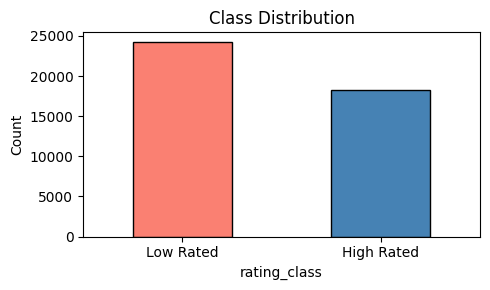

In [4]:
# ── CELL 4: Create Target Column ──
THRESHOLD = 6.0  # ✅ Fix 1: lowered from 7.0 to balance classes

df = df[df['vote_average'] > 0]  # Remove unrated movies
df['rating_class'] = (df['vote_average'] >= THRESHOLD).astype(int)

print(f'Threshold: {THRESHOLD}')
print(f'\nClass Distribution:')
print(df['rating_class'].value_counts())
print(f'\n  0 = Low rated  (< {THRESHOLD})')
print(f'  1 = High rated (>= {THRESHOLD})')

# Visualize class balance
plt.figure(figsize=(5,3))
df['rating_class'].value_counts().plot(kind='bar', color=['salmon','steelblue'], edgecolor='black')
plt.xticks([0,1], ['Low Rated','High Rated'], rotation=0)
plt.title('Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [5]:
# ── CELL 5: Feature Engineering ──

# Numeric features
numeric_features = ['budget', 'popularity', 'runtime', 'revenue', 'vote_count']
df[numeric_features] = df[numeric_features].fillna(0)

# Extract first genre
def extract_first_genre(genre_str):
    try:
        genres = ast.literal_eval(genre_str)
        return genres[0]['name'] if genres else 'Unknown'
    except:
        return 'Unknown'

df['main_genre'] = df['genres'].apply(extract_first_genre)
genre_dummies = pd.get_dummies(df['main_genre'], prefix='genre')

# Collection feature
df['in_collection'] = df['belongs_to_collection'].apply(
    lambda x: 0 if pd.isna(x) or x == '' else 1
)

# Final feature matrix
feature_cols = numeric_features + ['in_collection']
X = pd.concat([df[feature_cols], genre_dummies], axis=1)
y = df['rating_class']

print(f'Total features: {X.shape[1]}')
print(f'Feature list: {list(X.columns)}')

Total features: 27
Feature list: ['budget', 'popularity', 'runtime', 'revenue', 'vote_count', 'in_collection', 'genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Comedy', 'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Family', 'genre_Fantasy', 'genre_Foreign', 'genre_History', 'genre_Horror', 'genre_Music', 'genre_Mystery', 'genre_Romance', 'genre_Science Fiction', 'genre_TV Movie', 'genre_Thriller', 'genre_Unknown', 'genre_War', 'genre_Western']


In [6]:
# ── CELL 6: Train/Test Split ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size : {X_train.shape[0]}')
print(f'Test size  : {X_test.shape[0]}')

Train size : 33969
Test size  : 8493


In [7]:
# ── CELL 7: Scale Features ──
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('✅ Features scaled!')

✅ Features scaled!


In [8]:
# ── CELL 8: Fix Class Imbalance with SMOTE ──
print('Before SMOTE:')
print(pd.Series(y_train).value_counts())

sm = SMOTE(random_state=42)
X_train_scaled, y_train = sm.fit_resample(X_train_scaled, y_train)

print('\nAfter SMOTE:')
print(pd.Series(y_train).value_counts())
print('✅ Classes balanced!')

Before SMOTE:
rating_class
1    19394
0    14575
Name: count, dtype: int64



After SMOTE:
rating_class
0    19394
1    19394
Name: count, dtype: int64
✅ Classes balanced!


Best K = 12  |  CV Accuracy = 0.6670


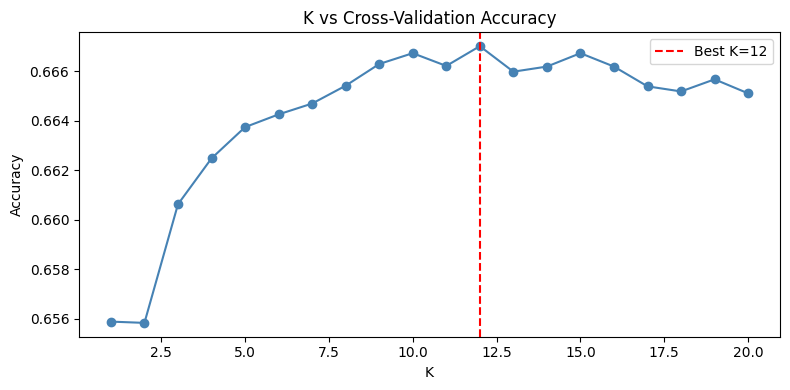

In [9]:
# ── CELL 9: Find Best K ──
k_range = range(1, 21)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', weights='distance')
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k = list(k_range)[np.argmax(cv_scores)]
print(f'Best K = {best_k}  |  CV Accuracy = {max(cv_scores):.4f}')

plt.figure(figsize=(8,4))
plt.plot(k_range, cv_scores, marker='o', color='steelblue')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.title('K vs Cross-Validation Accuracy')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# ── CELL 10: Train Final Model ──
# ✅ Fix 2: weights='distance' helps with imbalanced classes
knn = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean', weights='distance')
knn.fit(X_train_scaled, y_train)

print(f'✅ Model trained with K={best_k}')

✅ Model trained with K=12


In [11]:
# ── CELL 11: Evaluate Model ──
y_pred = knn.predict(X_test_scaled)

print('='*50)
print('MODEL EVALUATION')
print('='*50)
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Low rated', 'High rated']))

MODEL EVALUATION
Accuracy: 0.6238

Classification Report:
              precision    recall  f1-score   support

   Low rated       0.56      0.62      0.59      3644
  High rated       0.69      0.63      0.66      4849

    accuracy                           0.62      8493
   macro avg       0.62      0.62      0.62      8493
weighted avg       0.63      0.62      0.63      8493



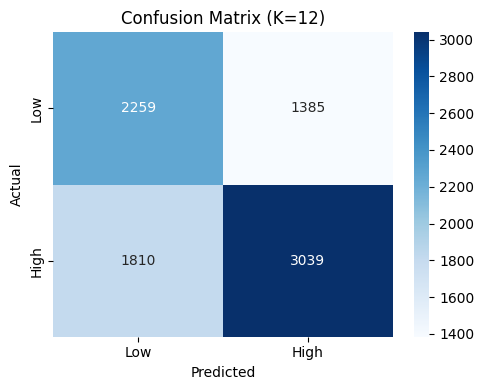

In [12]:
# ── CELL 12: Confusion Matrix ──
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low','High'],
            yticklabels=['Low','High'])
plt.title(f'Confusion Matrix (K={best_k})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()